In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1 Load the dataset

df = pd.read_csv('/Users/Macbook/Documents/Jupyter/diabetes_medication_clinical_trial1_3.csv')

df.head()
df.info()
df.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   object 
 2   age                1400 non-null   int64  
 3   gender             1400 non-null   object 
 4   duration_diabetes  1400 non-null   int64  
 5   initial_hba1c      1400 non-null   float64
 6   hba1c              1400 non-null   float64
 7   time               1400 non-null   int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 98.6+ KB


,subject_id,age,duration_diabetes,initial_hba1c,hba1c,time
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,55.250000,10.450000,8.465500,7.686029,12.000000
std,57.754936,9.530602,5.805306,0.869367,1.106412,8.002859
min,1.000000,40.000000,1.000000,7.000000,4.700000,0.000000
25%,50.750000,46.000000,5.000000,7.700000,6.980000,4.000000
50%,100.500000,56.000000,11.000000,8.450000,7.700000,12.000000
75%,150.250000,64.000000,16.000000,9.125000,8.500000,20.000000
max,200.000000,70.000000,20.000000,10.000000,10.000000,24.000000


In [3]:
# Step 2 Data Exploration

print(f"DataFrame Shape: {df.shape}")

# Step 3 Data Cleaning
print(f"Missing Values:\n{df.isnull().sum()}")

df = df.dropna()

df['time'] = pd.to_numeric(df['time'], errors='coerce')



DataFrame Shape: (1400, 9)
Missing Values:
subject_id              0
group                   0
age                     0
gender                  0
duration_diabetes       0
initial_hba1c           0
hba1c                   0
time                    0
adverse_event        1123
dtype: int64


In [4]:
# Convert 'group' to categorical
df['group'] = df['group'].astype('category')

df = pd.get_dummies(df, columns=['group'], drop_first=True)

df.rename(columns={'group_treatment': 'group_treatment'}, inplace=True)

print(df.head())
print(df.columns)



    subject_id  age  gender  duration_diabetes  initial_hba1c  hba1c  time  \
1            2   46    Male                 19            9.9    9.9     0   
3            4   59    Male                 19            8.9    8.9     0   
6            7   69  Female                 12            8.9    8.9     0   
7            8   44  Female                  1            8.8    8.8     0   
10          11   52  Female                  2            7.8    7.8     0   

   adverse_event  group_treatment  
1        Fatigue            False  
3       Headache             True  
6      Dizziness             True  
7       Headache             True  
10        Nausea             True  
Index(['subject_id', 'age', 'gender', 'duration_diabetes', 'initial_hba1c',
       'hba1c', 'time', 'adverse_event', 'group_treatment'],
      dtype='object')


In [5]:
# Convert all columns used in  modeling to numeric types
df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

df['time'] = pd.to_numeric(df['time'], errors='coerce')

df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')

avg_hba1c_treatment = df[df['group_treatment'] == 1]['hba1c'].mean()

avg_hba1c_placebo = df[df['group_treatment'] == 0]['hba1c'].mean()

print(avg_hba1c_treatment)



7.35985401459854


In [6]:
# Calculate average HbA1c for the treatment group
print(f"Average HbA1c for Treatment Group: {avg_hba1c_treatment}")
print(f"Average HbA1c for Placebo Group: {avg_hba1c_placebo}")

# Calculate change in HbA1c for each subject
df['hba1c_change'] = df.groupby('subject_id')['hba1c'].transform(lambda x: x.iloc[0])

# Count occurences of each type of adverse events 

adverse_events = df['adverse_event'].value_counts(0)

print(adverse_events)



Average HbA1c for Treatment Group: 7.35985401459854
Average HbA1c for Placebo Group: 8.139142857142858
adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64


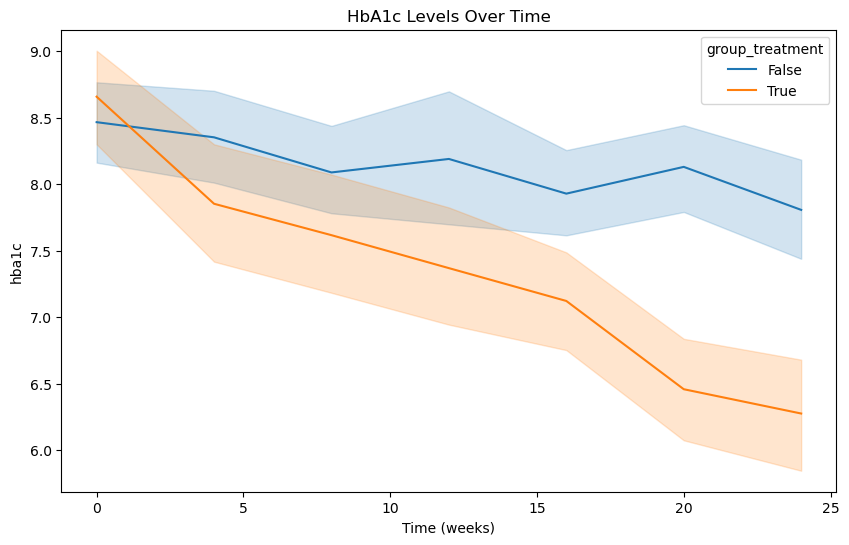

In [10]:
plt.figure(figsize=(10, 6))
# Plot HbA1c levels over time with treatment group colour coding

sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Levels Over Time') 

# Set the x-axis label
plt.xlabel('Time (weeks)') 

# Displays the plot
plt.show() 

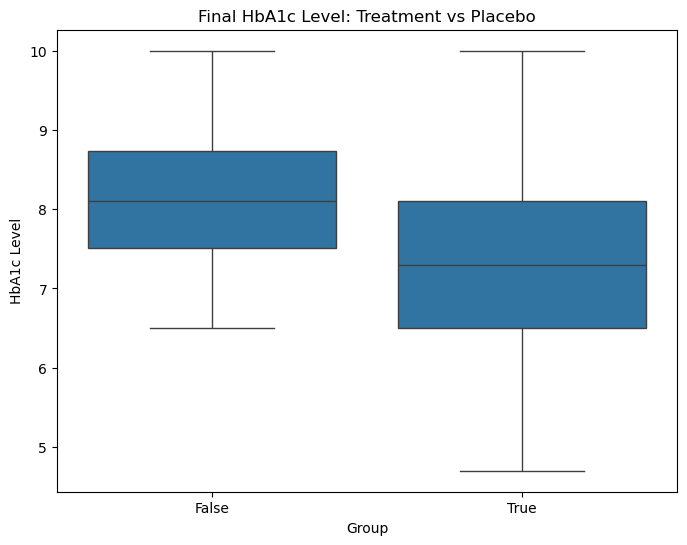

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='group_treatment', y='hba1c', data=df)
plt.title('Final HbA1c Level: Treatment vs Placebo')
plt.xlabel('Group')
plt.ylabel('HbA1c Level')
plt.show()



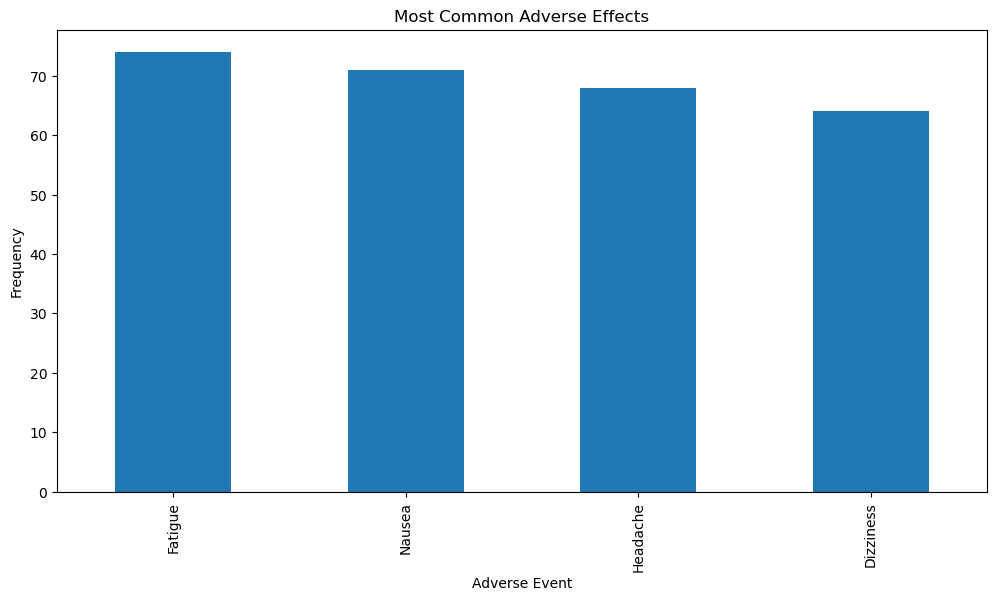

In [12]:
plt.figure(figsize=(12, 6))
adverse_events.plot(kind='bar')
plt.title('Most Common Adverse Effects')
plt.xlabel('Adverse Event')
plt.ylabel('Frequency')
plt.show()



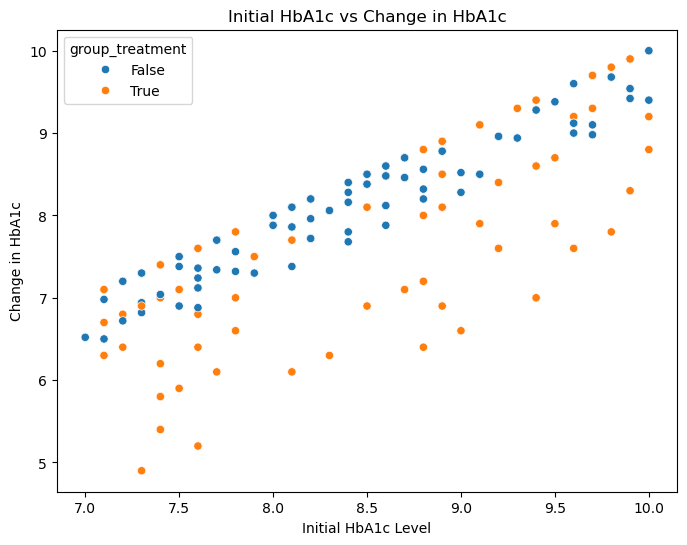

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change', hue='group_treatment', data=df)
plt.title('Initial HbA1c vs Change in HbA1c')
plt.xlabel('Initial HbA1c Level')
plt.ylabel('Change in HbA1c')
plt.show()

In [8]:
t_stat, p_val = stats.ttest_ind(df[df['group_treatment'] == 1]['hba1c'], df[df['group_treatment'] == 0]['hba1c'])
print(f"T-test result: {t_stat}, p-value = {p_val}")

# Perfrom ANOVA usuing statsmodel formula API
model = smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

# Use chi square test to compare adverse event rates between groups
adverse_event_table = pd.crosstab(df['group_treatment'], df['adverse_event'])



T-test result: -6.200485372339337, p-value = 2.0550724738165274e-09
                     sum_sq     df          F        PR(>F)
group_treatment   43.836941    1.0  50.782549  9.143732e-12
time              64.254098    1.0  74.434639  5.169343e-16
Residual         236.524596  274.0        NaN           NaN


chi-square test result: chi2 = 3.453364951919518, p-value = 0.3268610889706339


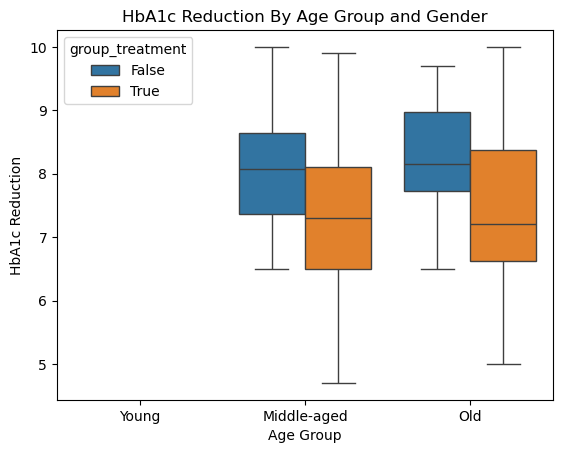

In [9]:
# Create a contingency table for adverse events by treatment group
chi2, p, dof, expected = stats.chi2_contingency(adverse_event_table, correction=False)
print(f"chi-square test result: chi2 = {chi2}, p-value = {p}")

if 'age_group' not in df.columns: # Check if age_group is missing
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['Young', 'Middle-aged', 'Old'])
    
# Create a box plot for HbA1c by age group and treatment group    

sns.boxplot(x='age_group', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Reduction By Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('HbA1c Reduction')
plt.show()